In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
tf.random.set_seed(100)

In [3]:
data = pd.read_csv('/content/KaggleV2-May-2016.csv')

In [5]:
data

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,2.572134e+12,5651768,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,3.596266e+12,5650093,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,1.557663e+13,5630692,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,9.213493e+13,5630323,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [6]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110527 entries, 0 to 110526
Data columns (total 14 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   PatientId       110527 non-null  float64
 1   AppointmentID   110527 non-null  int64  
 2   Gender          110527 non-null  object 
 3   ScheduledDay    110527 non-null  object 
 4   AppointmentDay  110527 non-null  object 
 5   Age             110527 non-null  int64  
 6   Neighbourhood   110527 non-null  object 
 7   Scholarship     110527 non-null  int64  
 8   Hipertension    110527 non-null  int64  
 9   Diabetes        110527 non-null  int64  
 10  Alcoholism      110527 non-null  int64  
 11  Handcap         110527 non-null  int64  
 12  SMS_received    110527 non-null  int64  
 13  No-show         110527 non-null  object 
dtypes: float64(1), int64(8), object(5)
memory usage: 11.8+ MB


In [7]:
data.describe()

,PatientId,AppointmentID,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received
count,1.105270e+05,1.105270e+05,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
mean,1.474963e+14,5.675305e+06,37.088874,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026
std,2.560949e+14,7.129575e+04,23.110205,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873
min,3.921784e+04,5.030230e+06,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.172614e+12,5.640286e+06,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,3.173184e+13,5.680573e+06,37.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,9.439172e+13,5.725524e+06,55.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,9.999816e+14,5.790484e+06,115.000000,1.000000,1.000000,1.000000,1.000000,4.000000,1.000000


In [8]:
print("Total missing values:", data.isna().sum().sum())

Total missing values: 0


In [4]:
data = data.drop(['PatientId', 'AppointmentID'], axis=1)

In [10]:
data


,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No
...,...,...,...,...,...,...,...,...,...,...,...,...
110522,F,2016-05-03T09:15:35Z,2016-06-07T00:00:00Z,56,MARIA ORTIZ,0,0,0,0,0,1,No
110523,F,2016-05-03T07:27:33Z,2016-06-07T00:00:00Z,51,MARIA ORTIZ,0,0,0,0,0,1,No
110524,F,2016-04-27T16:03:52Z,2016-06-07T00:00:00Z,21,MARIA ORTIZ,0,0,0,0,0,1,No
110525,F,2016-04-27T15:09:23Z,2016-06-07T00:00:00Z,38,MARIA ORTIZ,0,0,0,0,0,1,No


In [5]:
data = data.rename(columns={'ScheduledDay': "ScheduledDate", 'AppointmentDay': "AppointmentDate"})

data['ScheduledYear'] = data['ScheduledDate'].apply(lambda x: np.int(x[0:4]))
data['ScheduledMonth'] = data['ScheduledDate'].apply(lambda x: np.int(x[5:7]))
data['ScheduledDay'] = data['ScheduledDate'].apply(lambda x: np.int(x[8:10]))
data['ScheduledHour'] = data['ScheduledDate'].apply(lambda x: np.int(x[11:13]))
data['ScheduledMinute'] = data['ScheduledDate'].apply(lambda x: np.int(x[14:16]))
data['ScheduledSecond'] = data['ScheduledDate'].apply(lambda x: np.int(x[17:19]))

data['AppointmentYear'] = data['AppointmentDate'].apply(lambda x: np.int(x[0:4]))
data['AppointmentMonth'] = data['AppointmentDate'].apply(lambda x: np.int(x[5:7]))
data['AppointmentDay'] = data['AppointmentDate'].apply(lambda x: np.int(x[8:10]))

data = data.drop(['ScheduledDate', 'AppointmentDate'], axis=1)

<ipython-input-5-612a14371e26>:3: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  data['ScheduledYear'] = data['ScheduledDate'].apply(lambda x: np.int(x[0:4]))
<ipython-input-5-612a14371e26>:4: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional inf

In [12]:
data

,Gender,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,ScheduledYear,ScheduledMonth,ScheduledDay,ScheduledHour,ScheduledMinute,ScheduledSecond,AppointmentYear,AppointmentMonth,AppointmentDay
0,F,62,JARDIM DA PENHA,0,1,0,0,0,0,No,2016,4,29,18,38,8,2016,4,29
1,M,56,JARDIM DA PENHA,0,0,0,0,0,0,No,2016,4,29,16,8,27,2016,4,29
2,F,62,MATA DA PRAIA,0,0,0,0,0,0,No,2016,4,29,16,19,4,2016,4,29
3,F,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No,2016,4,29,17,29,31,2016,4,29
4,F,56,JARDIM DA PENHA,0,1,1,0,0,0,No,2016,4,29,16,7,23,2016,4,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,F,56,MARIA ORTIZ,0,0,0,0,0,1,No,2016,5,3,9,15,35,2016,6,7
110523,F,51,MARIA ORTIZ,0,0,0,0,0,1,No,2016,5,3,7,27,33,2016,6,7
110524,F,21,MARIA ORTIZ,0,0,0,0,0,1,No,2016,4,27,16,3,52,2016,6,7
110525,F,38,MARIA ORTIZ,0,0,0,0,0,1,No,2016,4,27,15,9,23,2016,6,7


In [13]:
{column: data[column].unique() for column in data.select_dtypes('object').columns}

{'Gender': array(['F', 'M'], dtype=object),
 'Neighbourhood': array(['JARDIM DA PENHA', 'MATA DA PRAIA', 'PONTAL DE CAMBURI',
        'REPÚBLICA', 'GOIABEIRAS', 'ANDORINHAS', 'CONQUISTA',
        'NOVA PALESTINA', 'DA PENHA', 'TABUAZEIRO', 'BENTO FERREIRA',
        'SÃO PEDRO', 'SANTA MARTHA', 'SÃO CRISTÓVÃO', 'MARUÍPE',
        'GRANDE VITÓRIA', 'SÃO BENEDITO', 'ILHA DAS CAIEIRAS',
        'SANTO ANDRÉ', 'SOLON BORGES', 'BONFIM', 'JARDIM CAMBURI',
        'MARIA ORTIZ', 'JABOUR', 'ANTÔNIO HONÓRIO', 'RESISTÊNCIA',
        'ILHA DE SANTA MARIA', 'JUCUTUQUARA', 'MONTE BELO',
        'MÁRIO CYPRESTE', 'SANTO ANTÔNIO', 'BELA VISTA', 'PRAIA DO SUÁ',
        'SANTA HELENA', 'ITARARÉ', 'INHANGUETÁ', 'UNIVERSITÁRIO',
        'SÃO JOSÉ', 'REDENÇÃO', 'SANTA CLARA', 'CENTRO', 'PARQUE MOSCOSO',
        'DO MOSCOSO', 'SANTOS DUMONT', 'CARATOÍRA', 'ARIOVALDO FAVALESSA',
        'ILHA DO FRADE', 'GURIGICA', 'JOANA D´ARC', 'CONSOLAÇÃO',
        'PRAIA DO CANTO', 'BOA VISTA', 'MORADA DE CAMBURI', 'SANT

In [6]:
def binary_encode(df, column, positive_value):
    df = df.copy()
    df[column] = df[column].apply(lambda x: 1 if x == positive_value else 0)
    return df

def onehot_encode(df, column, prefix):
    df = df.copy()
    dummies = pd.get_dummies(df[column], prefix=prefix)
    df = pd.concat([df, dummies], axis=1)
    df = df.drop(column, axis=1)
    return df

In [7]:
data = binary_encode(data, 'Gender', positive_value='M')
data = binary_encode(data, 'No-show', positive_value='Yes')
data = onehot_encode(data, 'Neighbourhood', prefix='N')

In [16]:
data

,Gender,Age,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show,ScheduledYear,...,N_SANTOS REIS,N_SEGURANÇA DO LAR,N_SOLON BORGES,N_SÃO BENEDITO,N_SÃO CRISTÓVÃO,N_SÃO JOSÉ,N_SÃO PEDRO,N_TABUAZEIRO,N_UNIVERSITÁRIO,N_VILA RUBIM
0,0,62,0,1,0,0,0,0,0,2016,...,0,0,0,0,0,0,0,0,0,0
1,1,56,0,0,0,0,0,0,0,2016,...,0,0,0,0,0,0,0,0,0,0
2,0,62,0,0,0,0,0,0,0,2016,...,0,0,0,0,0,0,0,0,0,0
3,0,8,0,0,0,0,0,0,0,2016,...,0,0,0,0,0,0,0,0,0,0
4,0,56,0,1,1,0,0,0,0,2016,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110522,0,56,0,0,0,0,0,1,0,2016,...,0,0,0,0,0,0,0,0,0,0
110523,0,51,0,0,0,0,0,1,0,2016,...,0,0,0,0,0,0,0,0,0,0
110524,0,21,0,0,0,0,0,1,0,2016,...,0,0,0,0,0,0,0,0,0,0
110525,0,38,0,0,0,0,0,1,0,2016,...,0,0,0,0,0,0,0,0,0,0


In [8]:
import pandas as pd
from sklearn.utils import resample

# Assuming data is your original dataset
# Separate the majority and minority classes
data_majority = data[data['No-show'] == 0]
data_minority = data[data['No-show'] == 1]

# Upsample the minority class
data_minority_upsampled = resample(data_minority,
                                 replace=True,  # Sample with replacement
                                 n_samples=len(data_majority),  # Match the majority class size
                                 random_state=42)  # Set a random seed for reproducibility

# Combine the upsampled minority class with the majority class
data_balanced = pd.concat([data_majority, data_minority_upsampled])

# Shuffle the DataFrame to randomize the order of samples
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Now, data_balanced contains a balanced dataset


In [9]:
y = data_balanced['No-show'].copy()
X = data_balanced.drop('No-show', axis=1).copy()

In [10]:
scaler = StandardScaler()

X = scaler.fit_transform(X)

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.75, random_state=100)

In [40]:
print("Class Distribution (Positive to Negative): {:.1f}% / {:.1f}%".format(y_train.mean() * 100, (1 - y_train.mean()) * 100))

Class Distribution (Positive to Negative): 50.0% / 50.0%


In [41]:
inputs = tf.keras.Input(shape=(X.shape[1]))
x = tf.keras.layers.Dense(64, activation='relu')(inputs)
x = tf.keras.layers.Dense(32, activation='relu')(x)
x = tf.keras.layers.Dense(16, activation='relu')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.Model(inputs, outputs)


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc')
    ]
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    batch_size=32,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        )
    ]
)


Epoch 1/100
3308/3308 [==============================] - 13s 4ms/step - loss: 0.6505 - accuracy: 0.6221 - auc: 0.6662 - val_loss: 0.6305 - val_accuracy: 0.6474 - val_auc: 0.6991
Epoch 2/100
3308/3308 [==============================] - 9s 3ms/step - loss: 0.6204 - accuracy: 0.6593 - auc: 0.7121 - val_loss: 0.6158 - val_accuracy: 0.6573 - val_auc: 0.7175
Epoch 3/100
3308/3308 [==============================] - 11s 3ms/step - loss: 0.6073 - accuracy: 0.6697 - auc: 0.7272 - val_loss: 0.6064 - val_accuracy: 0.6713 - val_auc: 0.7283
Epoch 4/100
3308/3308 [==============================] - 12s 4ms/step - loss: 0.5971 - accuracy: 0.6778 - auc: 0.7384 - val_loss: 0.6034 - val_accuracy: 0.6734 - val_auc: 0.7316
Epoch 5/100
3308/3308 [==============================] - 10s 3ms/step - loss: 0.5896 - accuracy: 0.6844 - auc: 0.7472 - val_loss: 0.5989 - val_accuracy: 0.6764 - val_auc: 0.7353
Epoch 6/100
3308/3308 [==============================] - 10s 3ms/step - loss: 0.5829 - accuracy: 0.6894 - auc: 

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Assuming X and y are your features and labels
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions on the validation set
y_val_pred = rf_model.predict(X_val)

# Evaluate the model
accuracy = accuracy_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")


In [22]:
model.evaluate(X_test, y_test)

1037/1037 [==============================] - 3s 3ms/step - loss: 0.4600 - accuracy: 0.7964 - auc: 0.7105


[0.45996910333633423, 0.7964051961898804, 0.710539698600769]

In [23]:
y_true = np.array(y_test)
y_pred = np.squeeze(np.array(model.predict(X_test) >= 0.5, dtype=np.int))

1037/1037 [==============================] - 2s 2ms/step


<ipython-input-23-c0623fde7feb>:2: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  y_pred = np.squeeze(np.array(model.predict(X_test) >= 0.5, dtype=np.int))


In [24]:
print("Classification Report:\n\n", classification_report(y_true, y_pred))

Classification Report:

               precision    recall  f1-score   support

           0       0.80      0.99      0.89     26427
           1       0.49      0.05      0.09      6732

    accuracy                           0.80     33159
   macro avg       0.64      0.52      0.49     33159
weighted avg       0.74      0.80      0.72     33159



In [25]:
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

Confusion Matrix:
 [[26072   355]
 [ 6396   336]]


In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Assuming X and y are your features and labels
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a Random Forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predictions on the validation set
y_val_pred = rf_model.predict(X_val)

# Evaluate the model
accuracy = accuracy_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")


Accuracy: 0.9451
ROC AUC: 0.9452


In [43]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

# Assuming X and y are your features and labels
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a base learner (Decision Tree)
base_learner = DecisionTreeClassifier(max_depth=3)

# Create an AdaBoost classifier
adaboost_model = AdaBoostClassifier(base_learner, n_estimators=50, random_state=42)

# Train the model
adaboost_model.fit(X_train, y_train)

# Predictions on the validation set
y_val_pred = adaboost_model.predict(X_val)

# Evaluate the model
accuracy = accuracy_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")


Accuracy: 0.6663
ROC AUC: 0.6664


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

# Assuming X and y are your features and labels
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
logreg_model = LogisticRegression(random_state=42)
logreg_model.fit(X_train, y_train)
y_val_pred_logreg = logreg_model.predict(X_val)
accuracy_logreg = accuracy_score(y_val, y_val_pred_logreg)
roc_auc_logreg = roc_auc_score(y_val, y_val_pred_logreg)

# # Support Vector Machine
# svm_model = SVC(random_state=42)
# svm_model.fit(X_train, y_train)
# y_val_pred_svm = svm_model.predict(X_val)
# accuracy_svm = accuracy_score(y_val, y_val_pred_svm)
# roc_auc_svm = roc_auc_score(y_val, y_val_pred_svm)

# k-Nearest Neighbors
knn_model = KNeighborsClassifier()
knn_model.fit(X_train, y_train)
y_val_pred_knn = knn_model.predict(X_val)
accuracy_knn = accuracy_score(y_val, y_val_pred_knn)
roc_auc_knn = roc_auc_score(y_val, y_val_pred_knn)

# Gradient Boosting
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)
y_val_pred_gb = gb_model.predict(X_val)
accuracy_gb = accuracy_score(y_val, y_val_pred_gb)
roc_auc_gb = roc_auc_score(y_val, y_val_pred_gb)

# Display results
print("Logistic Regression:")
print(f"Accuracy: {accuracy_logreg:.4f}")
print(f"ROC AUC: {roc_auc_logreg:.4f}\n")

# print("Support Vector Machine:")
# print(f"Accuracy: {accuracy_svm:.4f}")
# print(f"ROC AUC: {roc_auc_svm:.4f}\n")

print("k-Nearest Neighbors:")
print(f"Accuracy: {accuracy_knn:.4f}")
print(f"ROC AUC: {roc_auc_knn:.4f}\n")

print("Gradient Boosting:")
print(f"Accuracy: {accuracy_gb:.4f}")
print(f"ROC AUC: {roc_auc_gb:.4f}")


Logistic Regression:
Accuracy: 0.6324
ROC AUC: 0.6322

k-Nearest Neighbors:
Accuracy: 0.7423
ROC AUC: 0.7428

Gradient Boosting:
Accuracy: 0.6583
ROC AUC: 0.6585


In [14]:
import pandas as pd

# Results
results = {
    'Model': ['Logistic Regression', 'k-Nearest Neighbors', 'Gradient Boosting', 'Decision Tree', 'Random Forest', 'Neural Network'],
    'Accuracy': [0.6324, 0.7423, 0.6583, 0.6663, 0.9451, 0.80],
    'ROC AUC': [0.6322, 0.7428, 0.6585, 0.6664, 0.9452, '-']  # None for Neural Network since ROC AUC not provided
}

# Create DataFrame
results_df = pd.DataFrame(results)

# Display the DataFrame
print(results_df)


                 Model  Accuracy ROC AUC
0  Logistic Regression    0.6324  0.6322
1  k-Nearest Neighbors    0.7423  0.7428
2    Gradient Boosting    0.6583  0.6585
3        Decision Tree    0.6663  0.6664
4        Random Forest    0.9451  0.9452
5       Neural Network    0.8000       -


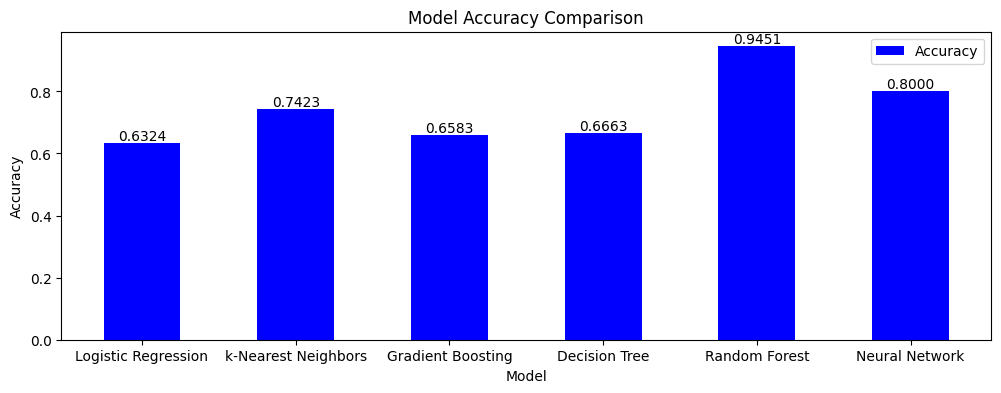

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming results_df is the DataFrame containing your results

# Set up the figure and axis
fig, ax = plt.subplots(figsize=(12, 4))

# Bar width
bar_width = 0.5

# Positions of bars on X-axis
index = np.arange(len(results_df['Model']))

# Plot Accuracy
bar1 = ax.bar(index, results_df['Accuracy'], bar_width, label='Accuracy', color='blue')

# Set labels, title, and legend
ax.set_xlabel('Model')
ax.set_ylabel('Accuracy')
ax.set_title('Model Accuracy Comparison')
ax.set_xticks(index)
ax.set_xticklabels(results_df['Model'])
ax.legend()

# Display the values on top of the bars
for bar, value in zip(bar1, results_df['Accuracy']):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height, f'{value:.4f}', ha='center', va='bottom')

plt.show()
